In [1]:
%autosave 60

Autosaving every 60 seconds


In [2]:
# !pip install -U catboost

In [3]:
# pip install numpy==1.25.0

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error

# boosting limitations

In [5]:
X = np.linspace(1, 10, 200)
y = X * np.sin(X)

X += np.random.normal(0, 0.15, 200)

In [6]:
X_fe = np.vstack([X, X ** 2, X ** 3, X ** (1/2), X ** (1/3)]).T

In [7]:
X_2 = np.linspace(10, 20, 200)
y_2 = X_2 * np.sin(X_2)

In [8]:
X_2_fe = np.vstack([X_2, X_2 ** 2, X_2 ** 3, X_2 ** (1/2), X_2 ** (1/3)]).T

In [14]:
# model = SVR()
model = GradientBoostingRegressor(n_estimators=400)
model = model.fit(X_fe, y)

pred = model.predict(X_fe)
pred_2 = model.predict(X_2_fe)

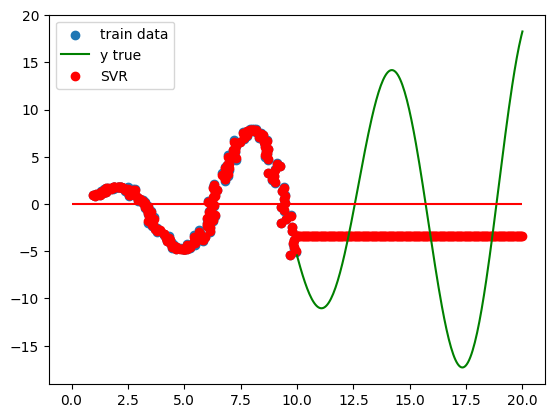

In [15]:
plt.scatter(X, y, label='train data')
plt.plot(X_2, y_2, color='green', label='y true')

plt.scatter(X, pred, color='red')
plt.scatter(X_2, pred_2, color='red', label='SVR')

plt.hlines(0, 0, 20, color='red',)

plt.legend()
plt.show()

# обучение boosting

In [20]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

In [21]:
from matplotlib import cm
rainbow_cmap = cm.get_cmap('gist_rainbow')

<ipython-input-21-f1fee69294c2>:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rainbow_cmap = cm.get_cmap('gist_rainbow')


In [17]:
# Генерация случайных данных
np.random.seed(42)
X = np.random.uniform(0, 10, 1000).reshape(-1, 1)
y = np.sin(X) + np.random.normal(0, 0.1, 1000).reshape(-1, 1)

In [18]:
# Параметры модели
learning_rate = 0.1
n_estimators = 10
max_depth = 3
reg_alpha = 0.1
reg_lambda = 0.1
scale_pos_weight = 0.5

# Создание весов объектов
weights = np.ones_like(y)
weights[y < 0] = scale_pos_weight

# Инициализация предсказаний
predictions = np.zeros_like(y)

# Списки для хранения предсказаний и весов
all_predictions = []
all_weights = []

# Цикл XGBoost алгоритма с учетом регуляризации и весов объектов
for _ in range(n_estimators):
    # Ошибки для текущей итерации
    errors = y - predictions

    # Обучение дерева решений на ошибках с регуляризацией
    tree = DecisionTreeRegressor(max_depth=max_depth)
    tree.fit(X, errors, sample_weight=weights.reshape(1, -1)[0])

    # Прогноз построенного дерева с учетом регуляризации
    tree_prediction = tree.predict(X).reshape(-1, 1)

    # Обновление предсказаний
    predictions += learning_rate * tree_prediction

    # Добавление предсказаний и весов в списки
    all_predictions.append(predictions.copy())
    all_weights.append(weights.copy())

In [19]:
sorted_idxs = np.argsort(X)

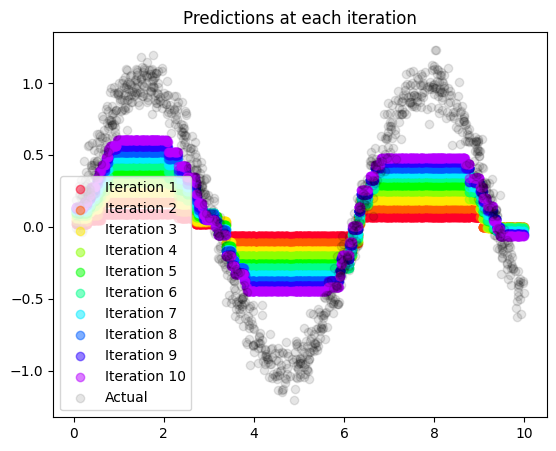

In [24]:
# Визуализация предсказаний на каждой итерации
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
for i, pred in enumerate(all_predictions):
    plt.scatter(X.reshape(1, -1)[0], pred.reshape(1, -1)[0], alpha=0.5, label=f"Iteration {i+1}", color=rainbow_cmap(i / len(all_predictions)))
plt.scatter(X, y, color='black', label='Actual', alpha=0.1)
plt.title("Predictions at each iteration")
plt.legend()
plt.show()

# xgboost key features

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

In [39]:
# Функция для расчета потерь (среднеквадратичная ошибка)
def loss_function(y_true, y_pred):
    """
    Расчет функции потерь между истинными и предсказанными значениями
    """
    return np.mean((y_true - y_pred) ** 2)

In [40]:
# Функция для расчета общих потерь согласно формуле XGBoost
def total_loss(y, F, T, gamma, lambd, w):
    """
    Расчет общей функции потерь XGBoost согласно формуле:
    total_loss = sum(loss(y_i, F(x_i))) + gamma * sum(T_k) + (1/2) * lambda * sum(||w_k||^2)

    Параметры:
    y - истинные значения
    F - предсказанные значения
    T - сложность деревьев (количество листьев)
    gamma - параметр регуляризации для сложности деревьев
    lambd - параметр L2-регуляризации
    w - веса деревьев
    """

    # Первый компонент: сумма потерь между истинными и предсказанными значениями
    loss_term = loss_function(y, F)

    # Второй компонент: регуляризация сложности деревьев
    complexity_term = gamma * sum(T)

    # Третий компонент: L2-регуляризация весов
    l2_term = (1/2) * lambd * sum(np.linalg.norm(w_k)**2 for w_k in w)

    # Общие потери
    return loss_term + complexity_term + l2_term, (loss_term, complexity_term, l2_term)

In [44]:
def simple_xgboost(X, y, n_trees=10, learning_rate=0.1, max_depth=3, gamma=0.1, lambd=0.1):
    # n_trees == n_estimators
    n_samples, n_features = X.shape

    # Инициализация предсказаний средним значением
    predictions = np.full(n_samples, np.mean(y))

    # Списки для хранения информации о модели и потерях
    trees = []
    weights = []
    tree_complexities = []
    total_losses = []
    loss_components = []


    # Цикл по количеству деревьев
    for i in range(n_trees):
        # Вычисление остатков (градиентов)
        residuals = y - predictions

        # Создание и обучение дерева решений на остатках
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=42)
        tree.fit(X, residuals)

        # Получение предсказаний дерева
        tree_preds = tree.predict(X)

        # Вес для текущего дерева
        weight = learning_rate  # ! можно влиять на вес

        # Обновление предсказаний
        predictions += weight * tree_preds

        # Сохранение дерева и его веса
        trees.append(tree)
        weights.append(weight)

        # Сложность дерева (количество листьев)
        tree_complexity = tree.get_n_leaves()
        tree_complexities.append(tree_complexity)

        # Вычисление текущих потерь и их компонентов
        current_total_loss, components = total_loss(
            y, predictions, tree_complexities, gamma, lambd, weights
        )
        total_losses.append(current_total_loss)
        loss_components.append(components)

        if i % 5 == 0:
          print(f"Дерево {i+1}:")
          print(f"  MSE потери: {components[0]:.4f}")
          print(f"  Регуляризация сложности: {components[1]:.4f}")
          print(f"  L2-регуляризация: {components[2]:.4f}")
          print(f"  Общие потери: {current_total_loss:.4f}")
          print()

    return predictions, trees, weights, total_losses, loss_components

In [45]:
# Создание фейковых данных с помощью make_regression
X, y = make_regression(n_samples=1000, n_features=5, noise=0.1, random_state=42)
# Нормализация целевой переменной для лучшей визуализации
y = (y - y.min()) / (y.max() - y.min()) * 10

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
# plt.plot([i[1] for i in components_low_reg])

In [46]:
final_predictions_low_reg, trees_low_reg, weights_low_reg, losses_low_reg, components_low_reg = simple_xgboost(
      X_train, y_train, n_trees=50, gamma=0.1, lambd=0.1, max_depth=3
)

Дерево 1:
  MSE потери: 2.4252
  Регуляризация сложности: 0.8000
  L2-регуляризация: 0.0005
  Общие потери: 3.2257

Дерево 6:
  MSE потери: 1.4143
  Регуляризация сложности: 4.8000
  L2-регуляризация: 0.0030
  Общие потери: 6.2173

Дерево 11:
  MSE потери: 0.9095
  Регуляризация сложности: 8.8000
  L2-регуляризация: 0.0055
  Общие потери: 9.7150

Дерево 16:
  MSE потери: 0.6241
  Регуляризация сложности: 12.8000
  L2-регуляризация: 0.0080
  Общие потери: 13.4321

Дерево 21:
  MSE потери: 0.4372
  Регуляризация сложности: 16.8000
  L2-регуляризация: 0.0105
  Общие потери: 17.2477

Дерево 26:
  MSE потери: 0.3139
  Регуляризация сложности: 20.8000
  L2-регуляризация: 0.0130
  Общие потери: 21.1269

Дерево 31:
  MSE потери: 0.2299
  Регуляризация сложности: 24.8000
  L2-регуляризация: 0.0155
  Общие потери: 25.0454

Дерево 36:
  MSE потери: 0.1711
  Регуляризация сложности: 28.8000
  L2-регуляризация: 0.0180
  Общие потери: 28.9891

Дерево 41:
  MSE потери: 0.1298
  Регуляризация сложност

# lightgbm key features

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from scipy.sparse import csr_matrix

In [59]:
# Функция для реализации EFB (Exclusive Feature Bundling)
def exclusive_feature_bundling(X, n_bundles=None, sparse_threshold=0.8):
    """
    Реализация Exclusive Feature Bundling для объединения взаимоисключающих признаков

    Параметры:
    X - матрица признаков
    n_bundles - количество пакетов (если None, определяется автоматически)
    sparse_threshold - порог разреженности для определения разреженных признаков

    Возвращает:
    X_bundled - матрица с объединенными признаками
    bundle_map - словарь отображения исходных признаков на пакеты
    """
    n_samples, n_features = X.shape

    # Определение разреженных признаков
    sparsity = np.sum(X == 0, axis=0) / n_samples
    sparse_features = np.where(sparsity >= sparse_threshold)[0]

    if len(sparse_features) == 0:
        print("Нет разреженных признаков для объединения")
        return X, {i: [i] for i in range(n_features)}

    # Определение количества пакетов, если не задано
    if n_bundles is None:
        n_bundles = max(1, len(sparse_features) // 2)

    # Создание графа конфликтов между признаками
    conflict_matrix = np.zeros((len(sparse_features), len(sparse_features)))

    for i in range(len(sparse_features)):
        for j in range(i+1, len(sparse_features)):
            feat_i = sparse_features[i]
            feat_j = sparse_features[j]

            # Проверка на конфликт (ненулевые значения в одних и тех же строках)
            conflict = np.sum((X[:, feat_i] != 0) & (X[:, feat_j] != 0)) / n_samples

            if conflict < 0.01:  # Допускаем небольшой процент конфликтов
                conflict_matrix[i, j] = conflict_matrix[j, i] = 0
            else:
                conflict_matrix[i, j] = conflict_matrix[j, i] = 1

    # Жадный алгоритм для объединения признаков
    bundles = []
    used_features = set()

    # Сортировка признаков по убыванию разреженности
    sorted_indices = np.argsort(-sparsity[sparse_features])

    for idx in sorted_indices:
        feat_idx = sparse_features[idx]

        if feat_idx in used_features:
            continue

        # Создание нового пакета
        current_bundle = [feat_idx]
        used_features.add(feat_idx)

        # Поиск признаков для добавления в текущий пакет
        for j in range(len(sparse_features)):
            feat_j = sparse_features[j]

            if feat_j in used_features:
                continue

            # Проверка конфликтов с текущим пакетом
            has_conflict = False
            for feat in current_bundle:
                idx_i = np.where(sparse_features == feat)[0][0]
                idx_j = j

                if conflict_matrix[idx_i, idx_j] == 1:
                    has_conflict = True
                    break

            if not has_conflict:
                current_bundle.append(feat_j)
                used_features.add(feat_j)

        bundles.append(current_bundle)

    # Добавление оставшихся не разреженных признаков как отдельные пакеты
    for i in range(n_features):
        if i not in used_features:
            bundles.append([i])

    # Ограничение количества пакетов
    if len(bundles) > n_bundles:
        # Объединение наименьших пакетов
        bundles.sort(key=len)
        while len(bundles) > n_bundles:
            smallest = bundles.pop(0)
            bundles[0].extend(smallest)

    # Создание новой матрицы признаков с объединенными пакетами
    X_bundled = np.zeros((n_samples, len(bundles)))
    bundle_map = {}

    for i, bundle in enumerate(bundles):
        # Смещение для каждого признака в пакете
        offset = 0
        bundle_map[i] = bundle

        for feat_idx in bundle:
            # Добавление признака с смещением
            non_zero_idx = X[:, feat_idx] != 0
            X_bundled[non_zero_idx, i] = X[non_zero_idx, feat_idx] + offset

            # Обновление смещения для следующего признака
            if np.max(X[:, feat_idx]) > 0:
                offset += np.max(X[:, feat_idx]) + 1

    print(f"EFB: Уменьшено количество признаков с {n_features} до {len(bundles)}")
    return X_bundled, bundle_map

In [ ]:
# Функция для реализации GOSS (Gradient-based One-Side Sampling)
def gradient_based_one_side_sampling(gradients, X, y, a=0.2, b=0.1):
    """
    Реализация Gradient-based One-Side Sampling для отбора наблюдений

    Параметры:
    gradients - градиенты для каждого наблюдения
    X - матрица признаков
    y - целевые значения
    a - доля наблюдений с наибольшими градиентами (top_rate)
    b - доля наблюдений с наименьшими градиентами (other_rate)

    Возвращает:
    X_sampled - отобранные признаки
    y_sampled - отобранные целевые значения
    weights - веса для отобранных наблюдений
    """
    n_samples = len(gradients)
    abs_gradients = np.abs(gradients)

    # Количество наблюдений для каждой группы
    n_top = int(n_samples * a)
    n_other = int(n_samples * b)

    # Индексы отсортированных градиентов
    sorted_idx = np.argsort(-abs_gradients)

    # Выбор наблюдений с наибольшими градиентами
    top_idx = sorted_idx[:n_top]

    # Случайный выбор из оставшихся наблюдений
    other_candidates = sorted_idx[n_top:]
    np.random.shuffle(other_candidates)
    other_idx = other_candidates[:n_other]

    # Объединение индексов
    selected_idx = np.concatenate([top_idx, other_idx])

    # Создание весов для компенсации выборки
    weights = np.ones(len(selected_idx))
    weights[n_top:] = (1 - a) / b  # Увеличиваем вес случайно выбранных наблюдений

    print(f"GOSS: Уменьшено количество наблюдений с {n_samples} до {len(selected_idx)} ({len(selected_idx)/n_samples:.2%})")

    return X[selected_idx], y[selected_idx], weights, selected_idx

# loss example 1
https://github.com/sb-ai-lab/LightAutoML/blob/b53830f84dc1ceec0112c7905be950304fafaa9f/lightautoml/tasks/losses/lgb_custom.py#L47

In [69]:
import numpy as np
from scipy.misc import derivative
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

In [70]:
def focal_loss(ytrue, ypred, gamma=2.0):
  p = 1 / (1 + np.exp(-ypred))
  loss = -(1 - ytrue) * p**gamma * np.log(1 - p) - ytrue * (1 - p)**gamma * np.log(p)
  return loss

def focal_loss_metric(ytrue, ypred):
  return 'focal_loss_metric', np.mean(focal_loss(ytrue, ypred)), False


def focal_loss_objective(ytrue, ypred):
  func = lambda z: focal_loss(ytrue, z)
  grad = derivative(func, ypred, n=1, dx=1e-6)
  # hess = derivative(func, ypred, n=2, dx=1e-6)
  return grad # , hess

In [71]:
import warnings
warnings.filterwarnings('ignore')

In [72]:
# Генерация данных для задачи классификации
X, y = make_classification(n_samples=1024, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, class_sep=1.5, random_state=42)


In [73]:
# Параметры модели
learning_rate = 0.1
n_estimators = 50
max_depth = 3
gamma = 2.0  # Параметр Focal Loss

In [74]:
# Создание весов объектов
weights = np.ones_like(y)

# Инициализация предсказаний
predictions = np.zeros_like(y, dtype=float)

# Списки для хранения предсказаний и весов
all_predictions = []
all_weights = []
all_errors = []

In [76]:
for _ in range(n_estimators):
    # Прогноз ошибки
    errors = focal_loss_objective(y, predictions)
    all_errors.append(errors)

    # Обучение дерева решений на ошибке
    tree = DecisionTreeRegressor(max_depth=max_depth)
    tree.fit(X, errors)

    # Прогноз построенного дерева
    tree_prediction = tree.predict(X)

    # Обновление предсказаний
    predictions += learning_rate * tree_prediction

    # Добавление предсказаний и весов в списки
    all_predictions.append(predictions.copy())
    all_weights.append(weights.copy())

In [79]:
# Создание весов объектов
weights = np.ones_like(y)

# Инициализация предсказаний
predictions = np.zeros_like(y, dtype=float)

# Списки для хранения предсказаний и весов
all_predictions_2 = []
all_weights_2 = []
all_errors_2 = []

def focal_loss_objective(ytrue, ypred):
  func = lambda z: focal_loss(ytrue, z, gamma=1)
  grad = derivative(func, ypred, n=1, dx=1e-6)
  # hess = derivative(func, ypred, n=2, dx=1e-6)
  return grad # , hess


for _ in range(n_estimators):
    # Прогноз ошибки
    errors = focal_loss_objective(y, predictions)
    all_errors_2.append(errors)

    # Обучение дерева решений на ошибке
    tree = DecisionTreeRegressor(max_depth=max_depth)
    tree.fit(X, errors)

    # Прогноз построенного дерева
    tree_prediction = tree.predict(X)

    # Обновление предсказаний
    predictions += learning_rate * tree_prediction

    # Добавление предсказаний и весов в списки
    all_predictions_2.append(predictions.copy())
    all_weights_2.append(weights.copy())


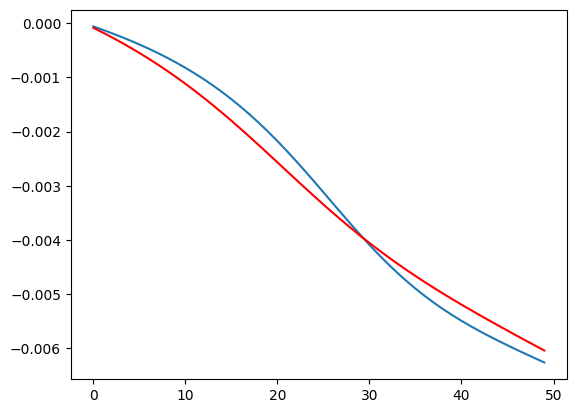

In [80]:
plt.plot([np.mean(i) for i in all_predictions])
plt.plot([np.mean(i) for i in all_predictions_2], color='red')

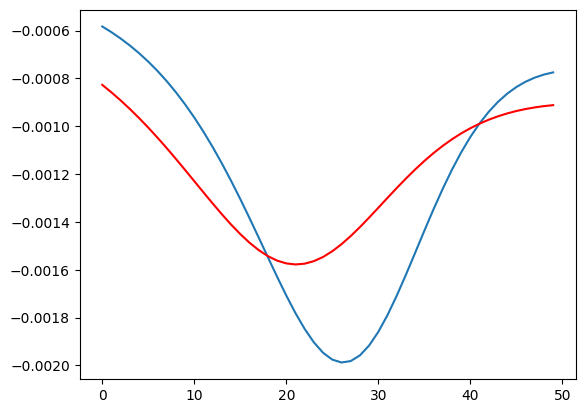

In [81]:
plt.plot([np.mean(i) for i in all_errors])
plt.plot([np.mean(i) for i in all_errors_2], color='red')

# hyperopt visualization

In [88]:
from hyperopt import hp, tpe, Trials, fmin, STATUS_OK
from sklearn.datasets import make_classification
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

In [82]:
from sklearn.datasets import load_diabetes
from sklearn.ensemble import HistGradientBoostingRegressor

X, y = load_diabetes(return_X_y=True, as_frame=True)

In [83]:
y = (y > y.mean()).astype(int)

In [85]:
def objective(params):
    # Создание модели Gradient Boosting с заданными параметрами

    max_depth = int(params['max_depth'])
    learning_rate = float(params['learning_rate'])


    model = GradientBoostingClassifier(
        n_estimators=100,
        max_depth=max_depth,
        learning_rate=learning_rate
    )

    # Кросс-валидация для оценки модели
    scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
    return {'loss': -np.mean(scores), 'status': STATUS_OK }

In [89]:
lr_space = np.linspace(0.001, 0.9, 60)
md_space = np.arange(1, 13, 1)

space = {
    'learning_rate': hp.choice('learning_rate', lr_space),
    'max_depth': hp.choice('max_depth', md_space)
}

# Инициализация Trials для записи результатов
# trials = Trials()

In [91]:
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=100, trials=trials)

 99%|█████████▉| 99/100 [02:14<00:01,  1.68s/trial, best loss: -0.8111418105703819]


In [102]:
trials.trials[0]['result']

{'loss': -0.8086959706959707, 'status': 'ok'}

In [103]:
losses = np.array([-trial['result']['loss'] for trial in trials.trials if trial['result'].get('loss')])

In [107]:
params_lr = np.array([
    lr_space[trial['misc']['vals']['learning_rate'][0]]
    for trial in trials.trials if trial['result'].get('loss')
    ])

params_md = np.array([
    md_space[trial['misc']['vals']['max_depth'][0]]
    for trial in trials.trials if trial['result'].get('loss')
    ])

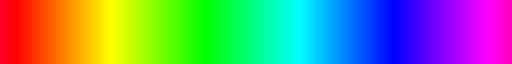

In [108]:
rainbow_cmap

Text(0, 0.5, 'max_depth')

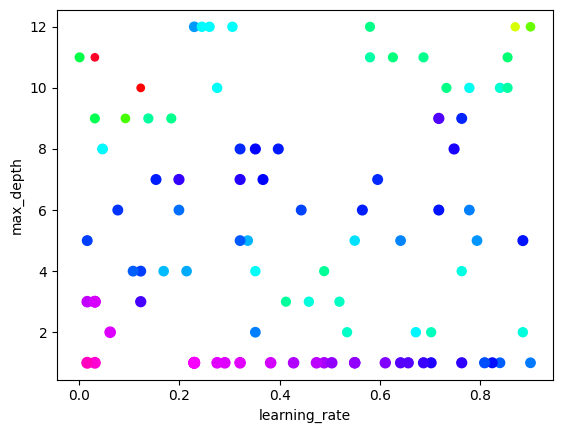

In [109]:
plt.scatter(params_lr, params_md, s=np.exp(losses * 5), marker='o', color=[
    rainbow_cmap(i)
    for i in [(i - np.min(losses)) / (np.max(losses) - np.min(losses)) for i in losses]
    ]
)

plt.xlabel('learning_rate')
plt.ylabel('max_depth')

### (1) анасамблирование : TODO, на дом
- https://habr.com/ru/articles/571296/
- https://education.yandex.ru/handbook/ml/article/ansambli-v-mashinnom-obuchenii
-----
- обучить несколько непохожих моделей (бустинги с разными гиперпараметрами / простые и линейные модели) на 45% данных data_1.
- получить предсказание на другие (45% (data_2) + 10% (data_3)) данных
- обучить мета модель на data_2, сделать предсказание на data_3 и оценить по метрике

#### (2) блендинг
- обучить несколько непохожих моделей (бустинги с разными гиперпараметрами / простые и линейные модели) на 80% данных data_1.
- получить предсказание на другие (20% (data_2)) данных
- строим мета объединение скоров и делаем один итоговый скор
-  сделать предсказание на data_2 и оценить по метрике

#### (3) auto ml
- check